Data loaded! Shape: (165034, 14)


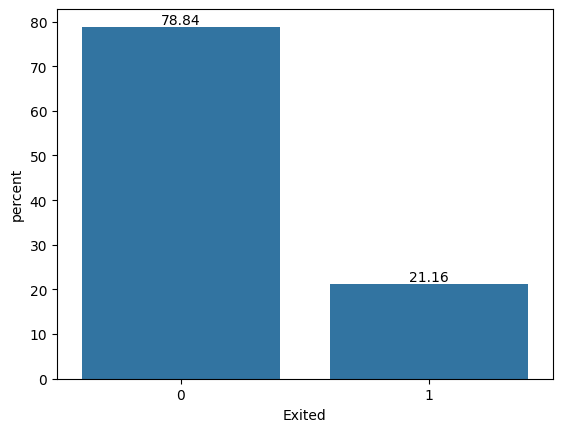

C:\Users\user\AppData\Local\Temp\ipykernel_5632\381678570.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x='Exited', y='Age', palette = 'Pastel1')
C:\Users\user\AppData\Local\Temp\ipykernel_5632\381678570.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x='Exited', y='Balance', palette = 'Pastel1')


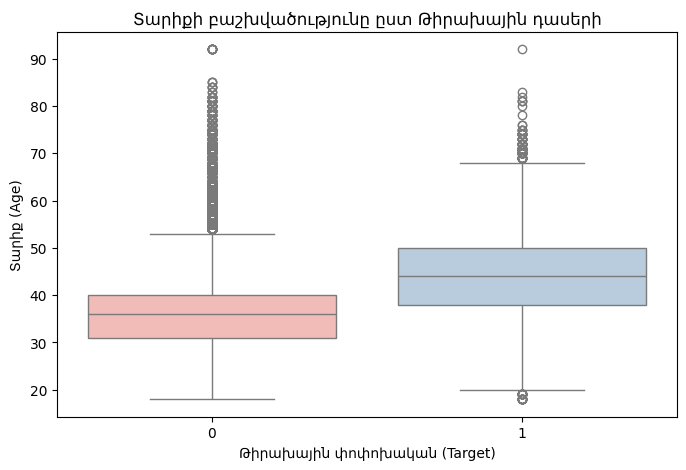

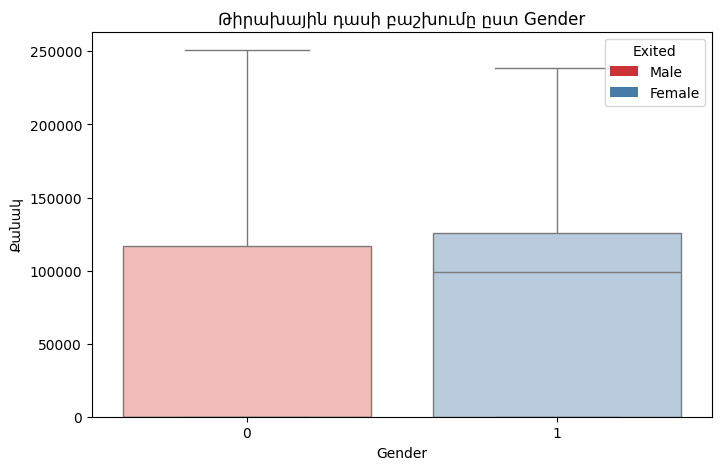

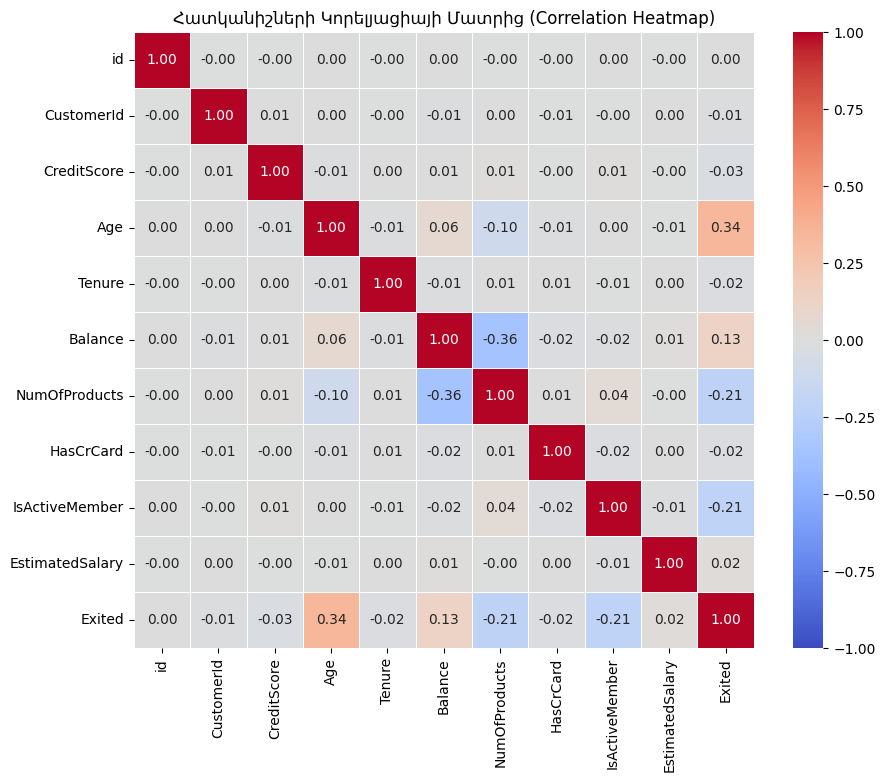

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

try:
    df = pd.read_csv('train.csv')
    print(f"Data loaded! Shape: {df.shape}")

except FileNotFoundError:
    print("Error: Ensure train.csv is in the directory.")

ax = sns.countplot (data = df, x='Exited', stat='percent')
ax.bar_label(ax.containers[0], fmt ='%.2f')
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(data= df, x='Exited', y='Age', palette = 'Pastel1')
plt.title("Տարիքի բաշխվածությունը ըստ Թիրախային դասերի")
plt.xlabel("Թիրախային փոփոխական (Target)")
plt.ylabel("Տարիք (Age)")



plt.figure(figsize=(8,5))
sns.boxplot(data= df, x='Exited', y='Balance', palette = 'Pastel1')
plt.title("Balanc բաշխվածությունը ըստ Թիրախային դասերի")
plt.xlabel("Թիրախային փոփոխական (Target)")
plt.ylabel("Balance")


sns.countplot(data=df, x='Exited', hue= 'Gender', palette='Set1')
plt.title("Թիրախային դասի բաշխումը ըստ Gender")
plt.xlabel("Gender")
plt.ylabel("Քանակ")
plt.legend(title = 'Exited', loc ='upper right')




numerical_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numerical_df.corr()

# 2. Գծում ենք Heatmap-ը
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm",  
    vmin=-1,  
    vmax=1,  
    linewidths=0.5,  
)

plt.title("Հատկանիշների Կորելյացիայի Մատրից (Correlation Heatmap)")
plt.show()

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

X = df.drop(columns=['id', 'Exited'])
y = df['Exited']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])





xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier())
])

param_xgb = {"model__n_estimators":[300], # 100. 200, 300
             "model__learning_rate": [0.1], #0.01, 0.05, 0.1
             "model__max_depth":[5]} #3,4,5,8

xgb_grid_search= GridSearchCV(
    xgb_pipeline,
    param_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)

xgb_grid_search.fit(X, y)

print("best param", xgb_grid_search.best_params_ )
print("best score: ", xgb_grid_search.best_score_)

best param {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}
best score:  0.8928284155561794


In [8]:
test_df = pd.read_csv("test.csv")
test_df
tableau_df = test_df.copy()

best_pipeline =  xgb_pipeline

best_pipeline.fit(X, y)


test_df = pd.read_csv("test.csv")
X_test = test_df.drop(columns=['id'])

test_probabilities = best_pipeline.predict_proba(X_test)[:, 1]
tableau_df['Churn_Probability'] = test_probabilities

def assign_risk(prob):
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.35:
        return 'Medium Risk'
    else:
        return 'Low Risk'

tableau_df['Risk_Category'] = tableau_df['Churn_Probability'].apply(assign_risk)

tableau_df.to_csv('bank_churn_for_tableau.csv', index=False)